In [1]:
!pip install pandas numpy scikit-learn tensorflow imblearn gradio matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.7/322.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.3 MB/s eta 0:00:00


In [89]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load data (already in your notebook)
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [90]:
data = data.drop('customerID', axis=1)

In [91]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

In [92]:
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
label_encoder = LabelEncoder()
for col in binary_cols:
    data[col] = label_encoder.fit_transform(data[col])

In [93]:
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [94]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)


In [95]:
from google.colab import drive
import pickle

drive.mount('/content/drive', force_remount=True)

# Save feature names for GUI
feature_names = X.columns.tolist()
with open('/content/drive/MyDrive/Churn_Models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Scale features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
X_train_numerical = scaler.fit_transform(X_train[numerical_cols])
X_val_numerical = scaler.transform(X_val[numerical_cols])
X_test_numerical = scaler.transform(X_test[numerical_cols])

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
X_train[numerical_cols] = X_train_numerical
X_val[numerical_cols] = X_val_numerical
X_test[numerical_cols] = X_test_numerical

# Save scaler for GUI
with open('/content/drive/MyDrive/Churn_Models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Scaler expects {scaler.n_features_in_} features")


Mounted at /content/drive
Scaler expects 3 features


In [96]:
from imblearn.over_sampling import SMOTE
import numpy as np

# Verify original class distribution
unique, counts = np.unique(y_train, return_counts=True)
print(f"Original X_train class distribution: {dict(zip(unique, counts))}")

# Apply SMOTE with adjusted sampling strategy
smote = SMOTE(sampling_strategy=0.8, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Verify class distribution after SMOTE
unique, counts = np.unique(y_train_smote, return_counts=True)
print(f"Class distribution after SMOTE: {dict(zip(unique, counts))}")

# Update X_train and y_train for training
X_train = X_train_smote
y_train = y_train_smote

Original X_train class distribution: {np.int64(0): np.int64(3622), np.int64(1): np.int64(1308)}
Class distribution after SMOTE: {np.int64(0): np.int64(3622), np.int64(1): np.int64(2897)}


In [97]:
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (6519, 30), y_train shape: (6519,)
X_val shape: (1056, 30), y_val shape: (1056,)
X_test shape: (1057, 30), y_test shape: (1057,)


In [98]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
import os

# Ensure Churn_Models directory exists
os.makedirs('/content/drive/MyDrive/Churn_Models', exist_ok=True)

# Define model architectures
def create_model1(input_dim):
    model = Sequential([
        Input(shape=(30,)),  # Explicit Input layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),  # Added layer
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model2(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model3(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model4(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model5(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Model creators
model_creators = {
    'FNN': create_model1,
    'DNN': create_model2,
    'Regularized': create_model3,
    'WideNN': create_model4,
    'DeepRegularizedNN': create_model5
}

histories = {}

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train each model with each optimizer
input_dim = X_train.shape[1]
for model_name, create_model in model_creators.items():
    for opt_name in ['Adam', 'RMSprop', 'SGD']:
        print(f"Training {model_name} with {opt_name}")

        # Create a fresh model instance
        model = create_model(input_dim)

        # Create a fresh optimizer instance
        if opt_name == 'Adam':
            optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
        elif opt_name == 'RMSprop':
            optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001)
        else:  # SGD
            optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

        # Compile the model
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

        # Train the model
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=32,
            callbacks=[early_stopping],
            verbose=1
        )

        # Store training history
        histories[f"{model_name}_{opt_name}"] = history.history

        # Save the trained model in .keras format
        model.save(f"/content/{model_name}_{opt_name}.keras")

        model_path = f"/content/drive/MyDrive/Churn_Models/{model_name}_{opt_name}.keras"
        model.save(model_path)
        print(f"Saved model to {model_path}")

import pickle
with open('/content/drive/MyDrive/Churn_Models/histories.pkl', 'wb') as f:
    pickle.dump(histories, f)

# Verify saved models
print("Models saved:")
for file in os.listdir('/content/drive/MyDrive/Churn_Models'):
    if file.endswith('.keras'):
        size = os.path.getsize(f'/content/drive/MyDrive/Churn_Models/{file}') / 1024
        print(f"{file}: {size:.2f} KB")

Training FNN with Adam
Epoch 1/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6865 - loss: 0.5681 - val_accuracy: 0.7443 - val_loss: 0.5161
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7753 - loss: 0.4641 - val_accuracy: 0.7623 - val_loss: 0.4788
Epoch 3/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7785 - loss: 0.4549 - val_accuracy: 0.7604 - val_loss: 0.4837
Epoch 4/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7786 - loss: 0.4495 - val_accuracy: 0.7623 - val_loss: 0.4755
Epoch 5/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7822 - loss: 0.4521 - val_accuracy: 0.7746 - val_loss: 0.4633
Epoch 6/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7875 - loss: 0.4320 - val_accuracy: 0.7282 - val_loss: 0.5172
Epoch 7/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7968 - loss: 0.4301 - val_accuracy: 0.7633 - val_loss: 0.4733
Epoch 8/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8090 -

In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
import tensorflow as tf

# Clear Keras session
tf.keras.backend.clear_session()

# Define model architectures
def create_model1(input_dim):
    model = Sequential([
        Input(shape=(30,)),  # Explicit Input layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),  # Added layer
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model2(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model3(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model4(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

def create_model5(input_dim):
    model = Sequential([
        Input(shape=(30,)),
        Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.005)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    return model

# Model creators
model_creators = {
    'FNN': create_model1,
    'DNN': create_model2,
    'Regularized': create_model3,
    'WideNN': create_model4,
    'DeepRegularizedNN': create_model5
}

# Evaluate each model on test set
test_results = {}
for model_name, create_model in model_creators.items():
    for opt_name in ['Adam', 'RMSprop', 'SGD']:
        print(f"Evaluating {model_name} with {opt_name}")

        # Load the saved model
        model = load_model(f"/content/{model_name}_{opt_name}.keras")

        # Predict on test set
        y_pred = (model.predict(X_test) > 0.5).astype(int)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Store results
        test_results[f"{model_name}_{opt_name}"] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

# Print test results
for model_opt, metrics in test_results.items():
    print(f"\n{model_opt}:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")

Evaluating FNN with Adam
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Evaluating FNN with RMSprop
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Evaluating FNN with SGD
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Evaluating DNN with Adam
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Evaluating DNN with RMSprop
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Evaluating DNN with SGD
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Evaluating Regularized with Adam
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Evaluating Regularized with RMSprop
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Evaluating Regularized with SGD
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Evaluating WideNN with Adam
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Evaluating WideNN with RMSprop
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Evaluating WideNN with SGD
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Evaluating DeepRegularizedNN with Adam
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Evaluating DeepRegularizedNN with RMSprop
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Evaluating DeepRegularizedNN w

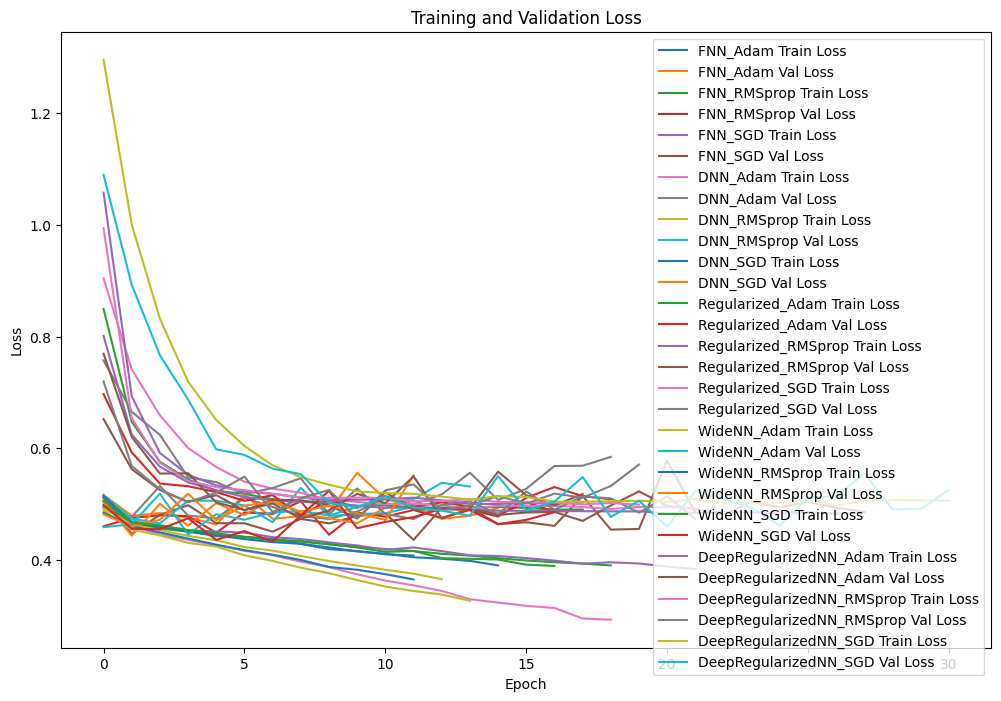

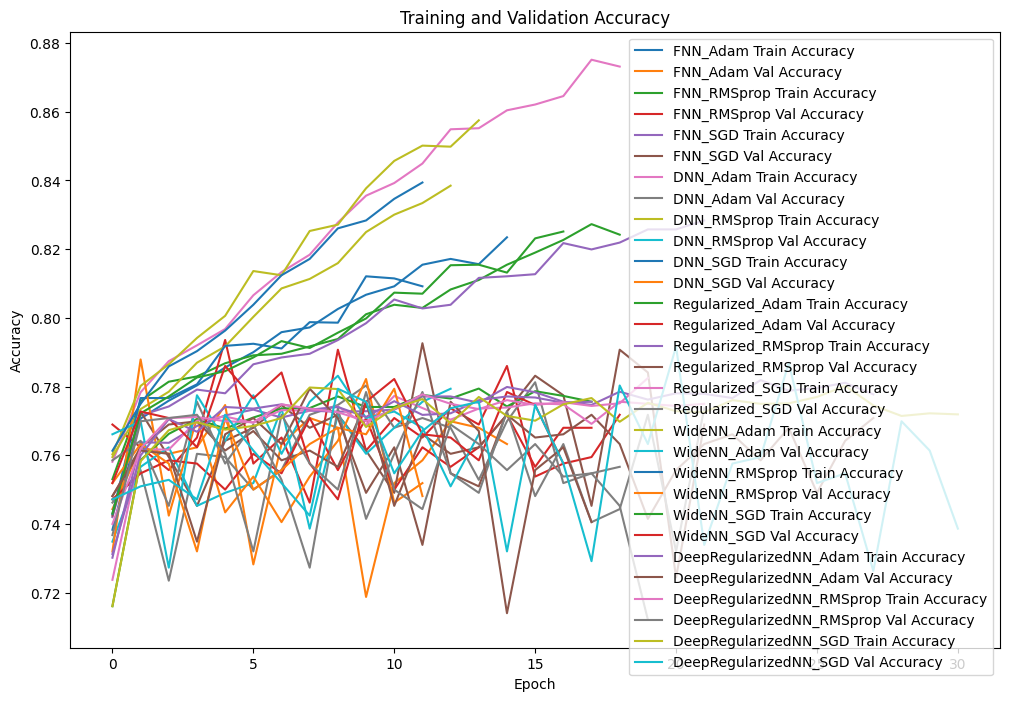

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for model_opt, history in histories.items():
    plt.plot(history['loss'], label=f'{model_opt} Train Loss')
    plt.plot(history['val_loss'], label=f'{model_opt} Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(12, 8))
for model_opt, history in histories.items():
    plt.plot(history['accuracy'], label=f'{model_opt} Train Accuracy')
    plt.plot(history['val_accuracy'], label=f'{model_opt} Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [79]:
import shutil
for file in os.listdir('/content'):
    if file.endswith('.keras'):
        shutil.move(f'/content/{file}', f'/content/drive/MyDrive/Churn_Models/{file}')

In [80]:
import pickle
with open('/content/training_histories.pkl', 'wb') as f:
    pickle.dump(histories, f)
with open('/content/test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'DSC_0067.JPG', 'IMG_0042.JPG', 'IMG_0038.JPG', 'DSC_0053.JPG', 'IMG_0048.JPG', 'DSC_0021.JPG', 'شهادات هويدا فاروق.pdf', 'Microsoft_Office_FrontPage_2003_(English)', '5بيكس.pptx', 'Microsoft_Office_FrontPage_2003_(English).rar (Unzipped Files)', 'Previous Certificates_AYA HESHAM IBRAHIM IBRAHIM MOHAMED_1442.pdf', "Mother's passport.pdf", 'C', 'التوكيل (1).pdf', 'التوكيل.pdf', 'COVID vaccinations.pdf', 'Share with CamScanner.zip', 'Untitled document.gdoc', 'Final Project Dr.Pet CS283', 'Untitled video.mp4', 'b56225fb-5cd1-4fce-bad3-32f59abb237e.jpeg', 'IMG_2655.heic', 'IMG_2656.heic', 'CamScanner 05-02-2024 21.07(1).pdf', 'CamScanner 05-02-2024 21.07.pdf', 'gameMini-LAPTOP-G2MQO5VI.rar', 'gameMini-LAPTOP-G2MQO5VI.zip', 'gameMini-LAPTOP-G2MQO5VI', 'DessertsElegants', 'LongGameLevel1.txt', 'LongGameLevel2.txt', 'LongGame.rar', 'LongGame.zip', 'Video.mov', 'react-task', 'Important‼️\n\nMSA 👩\u200d💻\nID   230489\nPassword(student zone)  Aya04hi\nPassword (e learning)  A

In [57]:
os.makedirs('/content/drive/MyDrive/Churn_Models', exist_ok=True)
print("Directory created or already exists")

Directory created or already exists


In [127]:
from google.colab import files

# Download all .keras files
for model_name in ['FNN', 'DNN', 'Regularized', 'WideNN', 'DeepRegularizedNN']:
    for opt_name in ['Adam', 'RMSprop', 'SGD']:
        file_path = f"/content/drive/MyDrive/Churn_Models/{model_name}_{opt_name}.keras"
        print(f"Downloading {file_path}")
        files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [82]:
!pip install gradio

In [60]:
import os
print(os.listdir('/content/drive/MyDrive/Churn_Models'))

['FNN_Adam.keras', 'FNN_RMSprop.keras', 'FNN_SGD.keras', 'DNN_Adam.keras', 'DNN_RMSprop.keras', 'DNN_SGD.keras', 'Regularized_Adam.keras', 'Regularized_RMSprop.keras', 'Regularized_SGD.keras', 'feature_names.pkl', 'test_results.pkl', 'scaler.pkl', 'WideNN_Adam.keras', 'WideNN_RMSprop.keras', 'WideNN_SGD.keras', 'DeepRegularizedNN_Adam.keras', 'DeepRegularizedNN_RMSprop.keras', 'DeepRegularizedNN_SGD.keras', 'histories.pkl']


In [61]:
feature_names = X.columns.tolist()
with open('/content/drive/MyDrive/Churn_Models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

In [62]:
with open('/content/drive/MyDrive/Churn_Models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [126]:
import gradio as gr
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
import pickle
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import BaseEstimator, ClassifierMixin
import tensorflow as tf
import os
from sklearn.utils.validation import check_is_fitted
from sklearn.linear_model import LogisticRegression

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Check Churn_Models directory
if not os.path.exists('/content/drive/MyDrive/Churn_Models'):
    raise FileNotFoundError("Churn_Models directory not found. Please run the training cell.")

# Load scaler and feature names
try:
    with open('/content/drive/MyDrive/Churn_Models/scaler.pkl', 'rb') as f:
        scaler = pickle.load(f)
    with open('/content/drive/MyDrive/Churn_Models/feature_names.pkl', 'rb') as f:
        feature_names = pickle.load(f)
except FileNotFoundError as e:
    raise FileNotFoundError("Scaler or feature_names file not found. Please re-run preprocessing.")

# Verify feature names and scaler
print(f"Loaded {len(feature_names)} feature names: {feature_names}")
print(f"Scaler expects {scaler.n_features_in_} features")
if len(feature_names) != 30:
    raise ValueError(f"Expected 30 feature names, got {len(feature_names)}")
if scaler.n_features_in_ != 3:
    raise ValueError(f"Scaler expects 3 features, got {scaler.n_features_in_}")

# Load or compute test_results
test_results = {}
test_results_path = '/content/drive/MyDrive/Churn_Models/test_results.pkl'
if os.path.exists(test_results_path):
    with open(test_results_path, 'rb') as f:
        test_results = pickle.load(f)
else:
    def compute_test_results():
        global test_results
        for model_name in ['FNN', 'DNN', 'Regularized', 'WideNN', 'DeepRegularizedNN']:
            for opt_name in ['Adam', 'RMSprop', 'SGD']:
                model_path = f"/content/drive/MyDrive/Churn_Models/{model_name}_{opt_name}.keras"
                if not os.path.exists(model_path):
                    print(f"Skipping {model_name}_{opt_name}: Model file not found")
                    continue
                # print(f"Computing metrics for {model_name} with {opt_name}")
                model = load_model(model_path)
                y_pred = (model.predict(X_test) > 0.5).astype(int)
                test_results[f"{model_name}_{opt_name}"] = {
                    'accuracy': accuracy_score(y_test, y_pred),
                    'precision': precision_score(y_test, y_pred),
                    'recall': recall_score(y_test, y_pred),
                    'f1': f1_score(y_test, y_pred)
                }
    try:
        compute_test_results()
        with open(test_results_path, 'wb') as f:
            pickle.dump(test_results, f)
    except NameError as e:
        raise NameError("X_test or y_test not defined. Please re-run preprocessing.")

# Custom Keras classifier for calibration
class KerasClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, model_path):
        self.model_path = model_path
        self.model = load_model(model_path)
        # Verify model output
        if self.model.output_shape != (None, 1):
            raise ValueError(f"Expected model output shape (None, 1), got {self.model.output_shape}")
        # Check activation of the last layer
        last_layer = self.model.layers[-1]
        if not hasattr(last_layer, 'activation') or last_layer.activation.__name__ != 'sigmoid':
            print(f"Warning: Last layer activation is {last_layer.activation.__name__}, expected sigmoid")
        self.classes_ = np.array([0, 1])  # Binary classification
        self._estimator_type = "classifier"  # Explicitly mark as classifier
        self._is_classifier = True  # Additional flag for scikit-learn
        self.is_fitted_ = False

    def fit(self, X, y):
        # Validate input shapes
        if X.shape[1] != 30:
            raise ValueError(f"Expected 30 features, got {X.shape[1]}")
        if not np.all(np.isin(np.unique(y), [0, 1])):
            raise ValueError("Expected binary labels (0, 1)")
        # Set fitted attributes
        self.is_fitted_ = True
        self.n_features_in_ = X.shape[1]
        self.classes_ = np.array([0, 1])
        self.n_classes_ = len(self.classes_)  # Explicitly set for classifier validation
        # print(f"KerasClassifier fitted with {X.shape[0]} samples, {X.shape[1]} features, estimator_type: {self._estimator_type}, classes: {self.classes_}, is_classifier: {self._is_classifier}, n_classes_: {self.n_classes_}")
        return self

    def predict_proba(self, X):
        check_is_fitted(self, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        # print(f"Predicting probabilities for input shape: {X.shape}")
        probs = self.model.predict(X, verbose=0)
        # Ensure probs is (n_samples, 1)
        if probs.ndim == 1:
            probs = probs.reshape(-1, 1)
        # Clip and normalize to ensure valid probabilities
        probs = np.clip(probs, 1e-10, 1 - 1e-10)  # Avoid 0 or 1 exactly
        result = np.hstack([1 - probs, probs])
        # Normalize to sum to 1
        result = result / np.sum(result, axis=1, keepdims=True)
        # print(f"predict_proba output shape: {result.shape}, sum of probs: {np.sum(result, axis=1)}")
        return result

    def predict(self, X):
        check_is_fitted(self, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        # print(f"Predicting for input shape: {X.shape}")
        probs = self.model.predict(X, verbose=0)
        return (probs > 0.5).astype(int).flatten()

    def decision_function(self, X):
        check_is_fitted(self, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        X = np.asarray(X, dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Expected {self.n_features_in_} features, got {X.shape[1]}")
        # print(f"Computing decision_function for input shape: {X.shape}")
        # Use log-odds for binary classification: log(p / (1-p))
        probs = self.model.predict(X, verbose=0)
        if probs.ndim == 1:
            probs = probs.reshape(-1, 1)
        probs = np.clip(probs, 1e-10, 1 - 1e-10)
        decision = np.log(probs / (1 - probs))
        # print(f"decision_function output shape: {decision.shape}")
        return decision.flatten()

# Function to map raw inputs to encoded features
def map_inputs_to_features(
    tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
    MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
    TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
):
    input_dict = {f: 0 for f in feature_names}
    input_dict['tenure'] = float(tenure)
    input_dict['MonthlyCharges'] = float(MonthlyCharges)
    input_dict['TotalCharges'] = float(TotalCharges)
    input_dict['gender'] = 1 if gender == 'Male' else 0
    input_dict['SeniorCitizen'] = 1 if SeniorCitizen == 'Yes' else 0
    input_dict['Partner'] = 1 if Partner == 'Yes' else 0
    input_dict['Dependents'] = 1 if Dependents == 'Yes' else 0
    input_dict['PhoneService'] = 1 if PhoneService == 'Yes' else 0
    input_dict['PaperlessBilling'] = 1 if PaperlessBilling == 'Yes' else 0
    input_dict['MultipleLines_No phone service'] = 1 if MultipleLines == 'No phone service' else 0
    input_dict['MultipleLines_Yes'] = 1 if MultipleLines == 'Yes' else 0
    input_dict['InternetService_Fiber optic'] = 1 if InternetService == 'Fiber optic' else 0
    input_dict['InternetService_No'] = 1 if InternetService == 'No' else 0
    input_dict['OnlineSecurity_No internet service'] = 1 if OnlineSecurity == 'No internet service' else 0
    input_dict['OnlineSecurity_Yes'] = 1 if OnlineSecurity == 'Yes' else 0
    input_dict['OnlineBackup_No internet service'] = 1 if OnlineBackup == 'No internet service' else 0
    input_dict['OnlineBackup_Yes'] = 1 if OnlineBackup == 'Yes' else 0
    input_dict['DeviceProtection_No internet service'] = 1 if DeviceProtection == 'No internet service' else 0
    input_dict['DeviceProtection_Yes'] = 1 if DeviceProtection == 'Yes' else 0
    input_dict['TechSupport_No internet service'] = 1 if TechSupport == 'No internet service' else 0
    input_dict['TechSupport_Yes'] = 1 if TechSupport == 'Yes' else 0
    input_dict['StreamingTV_No internet service'] = 1 if StreamingTV == 'No internet service' else 0
    input_dict['StreamingTV_Yes'] = 1 if StreamingTV == 'Yes' else 0
    input_dict['StreamingMovies_No internet service'] = 1 if StreamingMovies == 'No internet service' else 0
    input_dict['StreamingMovies_Yes'] = 1 if StreamingMovies == 'Yes' else 0
    input_dict['Contract_One year'] = 1 if Contract == 'One year' else 0
    input_dict['Contract_Two year'] = 1 if Contract == 'Two year' else 0
    input_dict['PaymentMethod_Credit card (automatic)'] = 1 if PaymentMethod == 'Credit card (automatic)' else 0
    input_dict['PaymentMethod_Electronic check'] = 1 if PaymentMethod == 'Electronic check' else 0
    input_dict['PaymentMethod_Mailed check'] = 1 if PaymentMethod == 'Mailed check' else 0
    input_df = pd.DataFrame([input_dict], columns=feature_names)
    # print(f"Input DataFrame shape: {input_df.shape}")
    if input_df.shape[1] != 30:
        raise ValueError(f"Input DataFrame has {input_df.shape[1]} columns, expected 30")
    input_array = input_df.values
    # print(f"Input array shape before scaling: {input_array.shape}")
    numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    numerical_data = input_df[numerical_cols].values
    scaled_numerical = scaler.transform(input_df[numerical_cols])
    numerical_indices = [feature_names.index(col) for col in numerical_cols]
    input_array[:, numerical_indices] = scaled_numerical
    # print(f"Input array shape after scaling: {input_array.shape}")
    if input_array.shape[1] != 30:
        raise ValueError(f"Final input array has {input_array.shape[1]} features, expected 30")
    return input_array

# Function to predict churn with manual calibration
def predict_churn(
    model_name, optimizer,
    tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
    MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
    TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
):
    try:
        model_path = f"/content/drive/MyDrive/Churn_Models/{model_name}_{optimizer}.keras"
        if not os.path.exists(model_path):
            return f"Model file not found: {model_path}. Please ensure the training cell has been run."

        # Load and pre-fit KerasClassifier
        keras_model = KerasClassifier(model_path)
        # print(f"Model output shape: {keras_model.model.output_shape}")
        # print(f"Last layer activation: {keras_model.model.layers[-1].activation.__name__}")
        # print(f"Fitting KerasClassifier for {model_name}_{optimizer} with X_val shape: {X_val.shape}")
        keras_model.fit(X_val, y_val)  # Mark as fitted
        check_is_fitted(keras_model, ['is_fitted_', 'n_features_in_', 'classes_', 'n_classes_'])
        # print(f"KerasClassifier is fitted: {keras_model.is_fitted_}, estimator_type: {keras_model._estimator_type}, classes: {keras_model.classes_}, is_classifier: {getattr(keras_model, '_is_classifier', False)}, n_classes_: {getattr(keras_model, 'n_classes_', None)}")

        # Manual calibration
        # print(f"Computing raw probabilities for X_val shape: {X_val.shape}")
        raw_probs = keras_model.predict_proba(X_val)[:, 1].reshape(-1, 1)  # Use class 1 probabilities
        # print(f"Raw probabilities shape: {raw_probs.shape}")
        if raw_probs.shape[1] != 1:
            raise ValueError(f"Expected raw_probs to have 1 feature, got {raw_probs.shape[1]}")
        calibrator = LogisticRegression()
        calibrator.fit(raw_probs, y_val)
        # print("Manual calibration completed")

        # Diagnostic: Check calibration effectiveness
        val_probs = calibrator.predict_proba(raw_probs)[:, 1]
        # print(f"Sample calibrated validation probabilities (first 10): {val_probs[:10]}")

        # Map inputs to features
        input_array = map_inputs_to_features(
            tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
            MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
            TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
        )

        # Predict with calibrated probabilities
        # print(f"Predicting with input shape: {input_array.shape}")
        raw_prob = keras_model.predict_proba(input_array)[:, 1].reshape(-1, 1)
        # print(f"Raw probability shape for prediction: {raw_prob.shape}")
        if raw_prob.shape[1] != 1:
            raise ValueError(f"Expected raw_prob to have 1 feature, got {raw_prob.shape[1]}")
        prob = calibrator.predict_proba(raw_prob)[0][1]
        churn = "Churn" if prob > 0.5 else "No Churn"

        # Get test metrics
        metrics = test_results.get(f"{model_name}_{optimizer}", {})
        metrics_str = (f"Accuracy: {metrics.get('accuracy', 'N/A'):.4f}\n"
                       f"Precision: {metrics.get('precision', 'N/A'):.4f}\n"
                       f"Recall: {metrics.get('recall', 'N/A'):.4f}\n"
                       f"F1 Score: {metrics.get('f1', 'N/A'):.4f}")

        return (f"Prediction: {churn}\n"
                f"Confidence: {prob:.4f}\n\n"
                f"Test Metrics:\n{metrics_str}")
    except Exception as e:
        return f"Error: {str(e)}"

# Gradio interface
with gr.Blocks() as demo:
    gr.Markdown("# Telco Customer Churn Prediction")
    with gr.Row():
        model_choice = gr.Dropdown(choices=['FNN', 'DNN', 'Regularized', 'WideNN', 'DeepRegularizedNN'], label="Select Model")
        optimizer_choice = gr.Dropdown(choices=['Adam', 'RMSprop', 'SGD'], label="Select Optimizer")
    gr.Markdown("### Customer Data")
    with gr.Row():
        tenure = gr.Slider(0, 72, label="Tenure (months)", step=1)
        MonthlyCharges = gr.Slider(0, 200, label="Monthly Charges ($)", step=0.1)
        TotalCharges = gr.Slider(0, 10000, label="Total Charges ($)", step=1)
    with gr.Row():
        gender = gr.Dropdown(choices=['Male', 'Female'], label="Gender")
        SeniorCitizen = gr.Dropdown(choices=['Yes', 'No'], label="Senior Citizen")
        Partner = gr.Dropdown(choices=['Yes', 'No'], label="Partner")
        Dependents = gr.Dropdown(choices=['Yes', 'No'], label="Dependents")
        PhoneService = gr.Dropdown(choices=['Yes', 'No'], label="Phone Service")
    with gr.Row():
        PaperlessBilling = gr.Dropdown(choices=['Yes', 'No'], label="Paperless Billing")
        MultipleLines = gr.Dropdown(choices=['No', 'Yes', 'No phone service'], label="Multiple Lines")
        InternetService = gr.Dropdown(choices=['DSL', 'Fiber optic', 'No'], label="Internet Service")
        Contract = gr.Dropdown(choices=['Month-to-month', 'One year', 'Two year'], label="Contract")
    with gr.Row():
        PaymentMethod = gr.Dropdown(choices=['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check'], label="Payment Method")
        OnlineSecurity = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Online Security")
        OnlineBackup = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Online Backup")
        DeviceProtection = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Device Protection")
    with gr.Row():
        TechSupport = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Tech Support")
        StreamingTV = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Streaming TV")
        StreamingMovies = gr.Dropdown(choices=['No', 'Yes', 'No internet service'], label="Streaming Movies")
    predict_button = gr.Button("Predict")
    output = gr.Textbox(label="Prediction and Metrics")
    predict_button.click(
        fn=predict_churn,
        inputs=[
            model_choice, optimizer_choice,
            tenure, MonthlyCharges, TotalCharges, gender, SeniorCitizen, Partner, Dependents, PhoneService,
            MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection,
            TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod
        ],
        outputs=output
    )

# Launch the interface
demo.launch(share=True, debug=True)

Mounted at /content/drive
Loaded 30 feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Scaler expects 3 features
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://5ecb2249b1fe4a24

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7872 <> https://5ecb2249b1fe4a2424.gradio.live
